 ## **Padel vs Tennis on Bluesky: Content Analysis**

**Course:** Web and Social Media Search and Analysis  
**Project type:** Social Media Analysis   
**Topic:** Padel vs Tennis online communities on Bluesky  
**Authors:** Marco Sabbadin , Marco Canetta




## Notebook logic
1. Load the cleaned dataset produced by the network analysis notebook (`clean_bluesky_posts.csv`).
2. Preprocess post text: tokenization, stopword removal, and cleaning.
3. Perform sentiment analysis using the AFINN lexicon.
4. Perform emotion analysis using the NRC Emotion Lexicon.
5. Extract named entities using spaCy (`en_core_web_sm`).
6. Analyse hashtag frequency for each topic.
7. Generate word clouds summarizing the most frequent terms.



In [ ]:

#!pip -q install atproto pandas numpy matplotlib networkx tqdm python-louvain

import os
import re
import json
import time
import math
import warnings
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

warnings.filterwarnings("ignore")

print("pandas:", pd.__version__)
print("networkx:", nx.__version__)

pandas: 2.2.2
networkx: 3.6.1


In [ ]:
PROJECT_NAME = "padel_vs_tennis_bluesky_network"

# Repository root: works both when the notebook is opened from /notebooks
# and when it is executed from the project root.
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
TABLE_DIR = DATA_DIR / "results"
FIG_DIR = BASE_DIR / "figures"

for folder in [DATA_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR, TABLE_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DEMO_MODE = False

# Maximum posts per topic. Increase for the final run if API limits and time allow.
MAX_POSTS_PER_TOPIC = 1000

# Optional date filters. Use ISO format with Z suffix for UTC.
SINCE = None
UNTIL = None

# Query design: use both plain keywords and topic-specific hashtags.
QUERIES = {
    "padel": [
        "padel",
        "#padel",
        "#PremierPadel",
        "#WorldPadelTour"
    ],
    "tennis": [
        "tennis",
        "#tennis",
        "#ATP",
        "#WTA",
        "#Wimbledon",
        "#RolandGarros",
        "#USOpen",
        "#AustralianOpen"
    ]
}

RAW_POSTS_PATH = RAW_DATA_DIR / "raw_bluesky_posts.csv"
CLEAN_POSTS_PATH = PROCESSED_DATA_DIR / "clean_bluesky_posts.csv"
EDGES_PATH = PROCESSED_DATA_DIR / "mention_edges.csv"
NODES_PATH = PROCESSED_DATA_DIR / "network_nodes.csv"

print("Project folder:", BASE_DIR.resolve())


Project folder: /content/padel_vs_tennis_bluesky_network


## 1. Data collection from Bluesky

The final dataset should include, for each post:

- `post_uri`
- `post_cid`
- `author_handle`
- `author_did`
- `text`
- `created_at`
- `reply_count`
- `repost_count`
- `like_count`
- `quote_count`
- `hashtags`
- `mentions`
- `links`
- `topic_label`
- `query_used`

The collection strategy is topic-based: posts are collected separately for padel and tennis and then merged. Users appearing in both datasets will later be treated as potential overlap or bridge users.

In [ ]:

!pip install atproto pandas numpy matplotlib networkx tqdm python-louvain

HANDLE = os.getenv("BLUESKY_HANDLE", "") #insert username 
APP_PASSWORD = os.getenv("BLUESKY_APP_PASSWORD", "") # insert password

client = None

if not DEMO_MODE:
    try:
        from atproto import Client, models
        from atproto_client.exceptions import RequestException
        if HANDLE and APP_PASSWORD:
            client = Client()
            client.login(HANDLE, APP_PASSWORD)
            print("Logged in to Bluesky as:", HANDLE)
        else:
            print("Credentials not found. Set HANDLE and APP_PASSWORD or use environment variables.")
            print("You can still run the notebook if a saved CSV exists, or set DEMO_MODE = True for testing.")
    except Exception as e:
        print("Could not initialize Bluesky client:", repr(e))
else:
    print("DEMO_MODE is active: no Bluesky login required.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.8/285.8 kB 25.5 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 48.0.0
    Uninstalling cryptography-48.0.0:
      Successfully uninstalled cryptography-48.0.0
Logged in to Bluesky as: canettamarco1@gmail.com


In [ ]:

def parse_dt_utc(iso_str):
    """Parse ISO datetime string and return timezone-aware UTC datetime."""
    if not iso_str or pd.isna(iso_str):
        return None
    dt = datetime.fromisoformat(str(iso_str).replace("Z", "+00:00"))
    if dt.tzinfo is None:
        return dt.replace(tzinfo=timezone.utc)
    return dt.astimezone(timezone.utc)


def safe_get(obj, attr, default=None):
    """Robust getter for nested AT Protocol objects."""
    try:
        return getattr(obj, attr, default)
    except Exception:
        return default


def extract_facets(record):
    """Extract hashtags, mentions, and links from a Bluesky post record."""
    hashtags, mentions, links = [], [], []
    facets = safe_get(record, "facets", None)
    if not facets:
        return {"hashtags": hashtags, "mentions": mentions, "links": links}

    for facet in facets:
        features = safe_get(facet, "features", []) or []
        for feat in features:
            py_type = str(safe_get(feat, "py_type", ""))
            if "tag" in py_type.lower():
                tag = safe_get(feat, "tag", None)
                if tag:
                    hashtags.append(str(tag).lower())
            elif "mention" in py_type.lower():
                did = safe_get(feat, "did", None)
                if did:
                    mentions.append(str(did))
            elif "link" in py_type.lower():
                uri = safe_get(feat, "uri", None)
                if uri:
                    links.append(str(uri))
    return {"hashtags": hashtags, "mentions": mentions, "links": links}


def extract_text_hashtags(text):
    """Fallback hashtag extraction from raw text."""
    if not isinstance(text, str):
        return []
    return [h.lower() for h in re.findall(r"#(\w+)", text)]


def normalize_list_column(x):
    """Convert a list-like object stored as list/string/NaN into a clean Python list."""
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        x = x.strip()
        if not x:
            return []
        try:
            parsed = json.loads(x.replace("'", '"'))
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass
        return [item.strip() for item in x.split(",") if item.strip()]
    return []


def post_to_row(post, topic_label, query_used):
    """Convert one Bluesky post object into a dictionary row."""
    record = safe_get(post, "record", None)
    author = safe_get(post, "author", None)
    facets = extract_facets(record)

    text = safe_get(record, "text", "") if record is not None else ""
    text_hashtags = extract_text_hashtags(text)
    hashtags = sorted(set(facets["hashtags"] + text_hashtags))

    row = {
        "post_uri": safe_get(post, "uri", None),
        "post_cid": safe_get(post, "cid", None),
        "author_handle": safe_get(author, "handle", None),
        "author_did": safe_get(author, "did", None),
        "author_display_name": safe_get(author, "display_name", None),
        "text": text,
        "created_at": safe_get(record, "created_at", None) if record is not None else None,
        "reply_count": safe_get(post, "reply_count", 0),
        "repost_count": safe_get(post, "repost_count", 0),
        "like_count": safe_get(post, "like_count", 0),
        "quote_count": safe_get(post, "quote_count", 0),
        "hashtags": hashtags,
        "mentions": facets["mentions"],
        "links": facets["links"],
        "topic_label": topic_label,
        "query_used": query_used,
    }
    return row

In [ ]:


def search_bluesky_posts(client, query, topic_label, max_posts=1000, since=None, until=None, pause=0.4):
    """Collect posts from Bluesky search using cursor pagination."""
    rows = []
    cursor = None

    if client is None:
        raise ValueError("Bluesky client is not initialized. Provide credentials or use DEMO_MODE.")

    pbar = tqdm(total=max_posts, desc=f"{topic_label}: {query}")
    while len(rows) < max_posts:
        try:
            params = {
                "q": query,
                "limit": min(100, max_posts - len(rows)),
            }
            if cursor:
                params["cursor"] = cursor
            if since:
                params["since"] = since
            if until:
                params["until"] = until

            response = client.app.bsky.feed.search_posts(params)
            posts = safe_get(response, "posts", []) or []
            cursor = safe_get(response, "cursor", None)

            if not posts:
                break

            for post in posts:
                rows.append(post_to_row(post, topic_label=topic_label, query_used=query))
                pbar.update(1)
                if len(rows) >= max_posts:
                    break

            if not cursor:
                break
            time.sleep(pause)

        except Exception as e:
            print(f"Error while collecting query '{query}':", repr(e))
            time.sleep(3)
            break

    pbar.close()
    return pd.DataFrame(rows)


def collect_all_topics(client, queries, max_posts_per_topic=1000, since=None, until=None):
    """Collect and merge posts for all topics."""
    all_frames = []
    per_query_limit = max(1, math.ceil(max_posts_per_topic / max(1, max(len(v) for v in queries.values()))))

    for topic, query_list in queries.items():
        topic_frames = []
        for query in query_list:
            df_q = search_bluesky_posts(
                client=client,
                query=query,
                topic_label=topic,
                max_posts=per_query_limit,
                since=since,
                until=until,
            )
            topic_frames.append(df_q)
        if topic_frames:
            df_topic = pd.concat(topic_frames, ignore_index=True)
            df_topic = df_topic.drop_duplicates(subset=["post_uri"])
            df_topic = df_topic.head(max_posts_per_topic)
            all_frames.append(df_topic)

    if not all_frames:
        return pd.DataFrame()

    df = pd.concat(all_frames, ignore_index=True)
    df = df.drop_duplicates(subset=["post_uri", "topic_label"])
    return df

In [ ]:


if DEMO_MODE:
    raw_df = make_demo_dataset()
    print("Using demo dataset. Rows:", len(raw_df))
elif RAW_POSTS_PATH.exists():
    raw_df = pd.read_csv(RAW_POSTS_PATH)
    print("Loaded existing raw dataset:", RAW_POSTS_PATH, "Rows:", len(raw_df))
elif client is not None:
    raw_df = collect_all_topics(
        client=client,
        queries=QUERIES,
        max_posts_per_topic=MAX_POSTS_PER_TOPIC,
        since=SINCE,
        until=UNTIL,
    )
    raw_df.to_csv(RAW_POSTS_PATH, index=False)
    print("Saved raw dataset to:", RAW_POSTS_PATH)
else:
    raw_df = pd.DataFrame()
    print("No data collected. Provide Bluesky credentials, upload a saved CSV, or set DEMO_MODE = True.")

raw_df.head()

padel: padel:   0%|          | 0/125 [00:00<?, ?it/s]

padel: #padel:   0%|          | 0/125 [00:00<?, ?it/s]

padel: #PremierPadel:   0%|          | 0/125 [00:00<?, ?it/s]

padel: #WorldPadelTour:   0%|          | 0/125 [00:00<?, ?it/s]

tennis: tennis:   0%|          | 0/125 [00:00<?, ?it/s]

...

tennis: #RolandGarros:   0%|          | 0/125 [00:00<?, ?it/s]

tennis: #USOpen:   0%|          | 0/125 [00:00<?, ?it/s]

tennis: #AustralianOpen:   0%|          | 0/125 [00:00<?, ?it/s]

Saved raw dataset to: padel_vs_tennis_bluesky_network/data/raw_bluesky_posts.csv


,post_uri,post_cid,author_handle,author_did,author_display_name,text,created_at,reply_count,repost_count,like_count,quote_count,hashtags,mentions,links,topic_label,query_used
0,at://did:plc:wfnerm5c2emfy4iffllxqlr5/app.bsky...,bafyreihbmk45wvwsl2zinu5zzjpthaod3ppl76mqyckvb...,andreafriz.bsky.social,did:plc:wfnerm5c2emfy4iffllxqlr5,il Friz 🐒,Ma quelli del padel stanno nel loro gabbiotto ...,2026-06-10T08:50:12.091Z,0,0,0,0,[],[],[],padel,padel
1,at://did:plc:36zpq6cbx7jmsoce2hr624v4/app.bsky...,bafyreic2zieczcvupdx6djmhvflnmevfq3ivtwpvsvoxp...,siisar.bsky.social,did:plc:36zpq6cbx7jmsoce2hr624v4,s11sar,Estado: buscando piso.\nEncontrado: la gran es...,2026-06-10T08:45:26.734Z,0,0,0,0,[],[],[],padel,padel
2,at://did:plc:4vmk2bts7rbvhlikpd5357ck/app.bsky...,bafyreie2pquewqbvnffh5bqybjgj6au67pkxol6cwefog...,shymon84.bsky.social,did:plc:4vmk2bts7rbvhlikpd5357ck,Shymon84 🍉,"Non si dice più racchettoni, si dice padel... 😁😁😁",2026-06-10T08:44:16.542Z,1,0,1,0,[],[],[],padel,padel
3,at://did:plc:eaxssnsscqcqspj7h4oeuxfj/app.bsky...,bafyreih22677rhscs77dc44hpmehtl4dxwrjraqr5z5kh...,pistacloud.bsky.social,did:plc:eaxssnsscqcqspj7h4oeuxfj,Pista,FIP SILVER MEDIOLANUM PADEL CUP\n\nQualifying ...,2026-06-10T08:41:39.856037Z,0,0,0,0,[],[],[],padel,padel
4,at://did:plc:eaxssnsscqcqspj7h4oeuxfj/app.bsky...,bafyreido4bzbyamwuxqqkwhycxk4zgj7owb4ippbsrdoi...,pistacloud.bsky.social,did:plc:eaxssnsscqcqspj7h4oeuxfj,Pista,FIP SILVER MEDIOLANUM PADEL CUP\n\nQualifying ...,2026-06-10T08:41:38.166883Z,0,0,0,0,[],[],[],padel,padel


## 2. Data cleaning and enrichment

This section normalizes list-like fields, removes duplicates, parses dates, and creates user-level topic labels:

- `padel_only`: user appears only in padel posts;
- `tennis_only`: user appears only in tennis posts;
- `both`: user appears in both topic datasets.

This variable is essential for answering whether the two communities overlap.

In [ ]:


if raw_df.empty:
    raise RuntimeError("The dataset is empty")

list_cols = ["hashtags", "mentions", "links"]
for col in list_cols:
    if col in raw_df.columns:
        raw_df[col] = raw_df[col].apply(normalize_list_column)
    else:
        raw_df[col] = [[] for _ in range(len(raw_df))]

clean_df = raw_df.copy()
clean_df["text"] = clean_df["text"].fillna("").astype(str)
clean_df["author_handle"] = clean_df["author_handle"].fillna("unknown_handle")
clean_df["author_did"] = clean_df["author_did"].fillna(clean_df["author_handle"])
clean_df["topic_label"] = clean_df["topic_label"].str.lower().str.strip()
clean_df["created_at"] = pd.to_datetime(clean_df["created_at"], errors="coerce", utc=True)

for col in ["reply_count", "repost_count", "like_count", "quote_count"]:
    clean_df[col] = pd.to_numeric(clean_df.get(col, 0), errors="coerce").fillna(0).astype(int)

# Remove exact duplicated posts inside the same topic.
clean_df = clean_df.drop_duplicates(subset=["post_uri", "topic_label"]).reset_index(drop=True)

# User topic type based on authored posts.
user_topics = clean_df.groupby("author_did")["topic_label"].apply(lambda x: sorted(set(x))).to_dict()

def classify_user_topic(author_did):
    topics = set(user_topics.get(author_did, []))
    if topics == {"padel"}:
        return "padel_only"
    if topics == {"tennis"}:
        return "tennis_only"
    if {"padel", "tennis"}.issubset(topics):
        return "both"
    return "unknown"

clean_df["author_topic_type"] = clean_df["author_did"].apply(classify_user_topic)
clean_df["engagement"] = clean_df[["reply_count", "repost_count", "like_count", "quote_count"]].sum(axis=1)
clean_df.to_csv(CLEAN_POSTS_PATH, index=False)

print("Clean dataset saved to:", CLEAN_POSTS_PATH)
print("Rows:", len(clean_df))
print("Unique authors:", clean_df["author_did"].nunique())
print("Topic distribution:")
display(clean_df["topic_label"].value_counts().to_frame("posts"))
print("User topic type distribution:")
display(clean_df.drop_duplicates("author_did")["author_topic_type"].value_counts().to_frame("users"))

clean_df.head(3)

Clean dataset saved to: padel_vs_tennis_bluesky_network/data/clean_bluesky_posts.csv
Rows: 1231
Unique authors: 453
Topic distribution:


,posts
topic_label,
tennis,931
padel,300


User topic type distribution:


,users
author_topic_type,
tennis_only,355
padel_only,88
both,10


,post_uri,post_cid,author_handle,author_did,author_display_name,text,created_at,reply_count,repost_count,like_count,quote_count,hashtags,mentions,links,topic_label,query_used,author_topic_type,engagement
0,at://did:plc:wfnerm5c2emfy4iffllxqlr5/app.bsky...,bafyreihbmk45wvwsl2zinu5zzjpthaod3ppl76mqyckvb...,andreafriz.bsky.social,did:plc:wfnerm5c2emfy4iffllxqlr5,il Friz 🐒,Ma quelli del padel stanno nel loro gabbiotto ...,2026-06-10 08:50:12.091000+00:00,0,0,0,0,[],[],[],padel,padel,padel_only,0
1,at://did:plc:36zpq6cbx7jmsoce2hr624v4/app.bsky...,bafyreic2zieczcvupdx6djmhvflnmevfq3ivtwpvsvoxp...,siisar.bsky.social,did:plc:36zpq6cbx7jmsoce2hr624v4,s11sar,Estado: buscando piso.\nEncontrado: la gran es...,2026-06-10 08:45:26.734000+00:00,0,0,0,0,[],[],[],padel,padel,padel_only,0
2,at://did:plc:4vmk2bts7rbvhlikpd5357ck/app.bsky...,bafyreie2pquewqbvnffh5bqybjgj6au67pkxol6cwefog...,shymon84.bsky.social,did:plc:4vmk2bts7rbvhlikpd5357ck,Shymon84 🍉,"Non si dice più racchettoni, si dice padel... 😁😁😁",2026-06-10 08:44:16.542000+00:00,1,0,1,0,[],[],[],padel,padel,padel_only,2


In [ ]:


summary_posts = (
    clean_df.groupby("topic_label")
    .agg(
        posts=("post_uri", "count"),
        unique_authors=("author_did", "nunique"),
        avg_likes=("like_count", "mean"),
        avg_reposts=("repost_count", "mean"),
        avg_replies=("reply_count", "mean"),
        avg_engagement=("engagement", "mean"),
    )
    .round(3)
)
summary_posts.to_csv(TABLE_DIR / "post_level_summary.csv")
display(summary_posts)

,posts,unique_authors,avg_likes,avg_reposts,avg_replies,avg_engagement
topic_label,,,,,,
padel,300,98,0.767,0.103,0.043,0.930
tennis,931,365,1.392,0.182,0.188,1.808


## 3. Network construction

The main network is a **directed user mention network**:

- **nodes** = Bluesky users;
- **directed edge** `A → B` = user `A` mentioned user `B` in a post;
- **edge weight** = number of mentions from `A` to `B`.

This network captures explicit interactions and allows centrality, community detection, and bridge-user analysis.

If mention data is sparse, the notebook also creates an optional **co-topic network** where users are connected when they participate in the same topic. However, the mention network is the main and most defensible social graph.

In [ ]:


# Map DIDs to readable handles using authors first.
did_to_handle = dict(zip(clean_df["author_did"], clean_df["author_handle"]))
handle_to_did = dict(zip(clean_df["author_handle"], clean_df["author_did"]))

edge_rows = []
for _, row in clean_df.iterrows():
    source = row["author_did"]
    source_handle = row["author_handle"]
    mentions = row["mentions"] if isinstance(row["mentions"], list) else []
    for target in mentions:
        if not target or target == source:
            continue
        edge_rows.append({
            "source": source,
            "source_handle": source_handle,
            "target": target,
            "target_handle": did_to_handle.get(target, target),
            "topic_label": row["topic_label"],
            "post_uri": row["post_uri"],
            "created_at": row["created_at"],
        })

edges_df = pd.DataFrame(edge_rows)

if edges_df.empty:
    print("No mention edges found. The mention network will be empty.")
else:
    # Aggregate repeated mentions.
    edges_weighted = (
        edges_df.groupby(["source", "target"])
        .agg(
            weight=("post_uri", "count"),
            topics=("topic_label", lambda x: sorted(set(x))),
            source_handle=("source_handle", "first"),
            target_handle=("target_handle", "first"),
        )
        .reset_index()
    )
    edges_weighted.to_csv(EDGES_PATH, index=False)
    display(edges_weighted.head())
    print("Edges saved to:", EDGES_PATH)
    print("Number of weighted edges:", len(edges_weighted))

,source,target,weight,topics,source_handle,target_handle
0,did:plc:6giah4xfhkhm5qnupurrubmt,did:plc:q26wuyujp2av5axczdwgzr3g,2,[tennis],michaelcdickens.bsky.social,tennistourtalk.bsky.social
1,did:plc:6xft23cyyeab5qz5yhuqouil,did:plc:krni4bugnyot7ycymbx76i2r,4,[tennis],winggirle.bsky.social,did:plc:krni4bugnyot7ycymbx76i2r
2,did:plc:6xft23cyyeab5qz5yhuqouil,did:plc:tdumzhz2mesu62guhwotgkto,4,[tennis],winggirle.bsky.social,atptour.stadio.top
3,did:plc:7kt2g5jmef47kkc7zchprjlj,did:plc:u46h6l4loixv4ihq3zequ6ht,1,[padel],padelspain.bsky.social,did:plc:u46h6l4loixv4ihq3zequ6ht
4,did:plc:elpkkhxsix7xq22z6r36idve,did:plc:oj5ynylmmargb5szeajr4nev,1,[tennis],taylorc97.bsky.social,did:plc:oj5ynylmmargb5szeajr4nev


Edges saved to: padel_vs_tennis_bluesky_network/data/mention_edges.csv
Number of weighted edges: 21


In [ ]:


G = nx.DiGraph()

# Add all authors as nodes, even if they have no outgoing mentions.
user_post_counts = clean_df.groupby("author_did").size().to_dict()
user_engagement = clean_df.groupby("author_did")["engagement"].sum().to_dict()
user_handles = clean_df.groupby("author_did")["author_handle"].first().to_dict()
user_topic_types = {u: classify_user_topic(u) for u in user_post_counts}
user_topic_sets = clean_df.groupby("author_did")["topic_label"].apply(lambda x: sorted(set(x))).to_dict()

for user_did in clean_df["author_did"].unique():
    G.add_node(
        user_did,
        handle=user_handles.get(user_did, user_did),
        topic_type=user_topic_types.get(user_did, "unknown"),
        topics=user_topic_sets.get(user_did, []),
        post_count=int(user_post_counts.get(user_did, 0)),
        engagement=int(user_engagement.get(user_did, 0)),
    )

# Add mentioned users not present as authors.
if not edges_df.empty:
    for _, edge in edges_weighted.iterrows():
        src = edge["source"]
        tgt = edge["target"]
        if tgt not in G:
            G.add_node(
                tgt,
                handle=edge.get("target_handle", tgt),
                topic_type="mentioned_only",
                topics=[],
                post_count=0,
                engagement=0,
            )
        G.add_edge(src, tgt, weight=int(edge["weight"]), topics=edge["topics"])

print("Graph created")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Is directed:", G.is_directed())

Graph created
Nodes: 471
Edges: 21
Is directed: True


In [ ]:

nodes_df = pd.DataFrame([
    {
        "node": n,
        "handle": data.get("handle", n),
        "topic_type": data.get("topic_type", "unknown"),
        "topics": data.get("topics", []),
        "post_count": data.get("post_count", 0),
        "engagement": data.get("engagement", 0),
        "in_degree": G.in_degree(n),
        "out_degree": G.out_degree(n),
        "weighted_in_degree": G.in_degree(n, weight="weight"),
        "weighted_out_degree": G.out_degree(n, weight="weight"),
    }
    for n, data in G.nodes(data=True)
])

nodes_df.to_csv(NODES_PATH, index=False)
display(nodes_df.head())
print("Nodes saved to:", NODES_PATH)

,node,handle,topic_type,topics,post_count,engagement,in_degree,out_degree,weighted_in_degree,weighted_out_degree
0,did:plc:wfnerm5c2emfy4iffllxqlr5,andreafriz.bsky.social,padel_only,[padel],1,0,0,0,0,0
1,did:plc:36zpq6cbx7jmsoce2hr624v4,siisar.bsky.social,padel_only,[padel],1,0,0,0,0,0
2,did:plc:4vmk2bts7rbvhlikpd5357ck,shymon84.bsky.social,padel_only,[padel],1,2,0,0,0,0
3,did:plc:eaxssnsscqcqspj7h4oeuxfj,pistacloud.bsky.social,padel_only,[padel],116,1,0,0,0,0
4,did:plc:2htr6vzopp6mejep7qcpszru,reporterre.net,padel_only,[padel],1,27,0,0,0,0


Nodes saved to: padel_vs_tennis_bluesky_network/data/network_nodes.csv


## 4. Graph-level comparison: padel vs tennis

To compare the two sport communities, the notebook builds:

- a full mention network;
- a padel subnetwork;
- a tennis subnetwork.

For each graph, it computes:

- number of nodes;
- number of edges;
- density;
- average degree;
- average clustering coefficient;
- number of weakly connected components;
- size of the largest connected component.

In [ ]:


def authors_for_topic(df, topic):
    return set(df.loc[df["topic_label"] == topic, "author_did"])

padel_authors = authors_for_topic(clean_df, "padel")
tennis_authors = authors_for_topic(clean_df, "tennis")
both_authors = padel_authors & tennis_authors

G_padel = G.subgraph([n for n in G.nodes if n in padel_authors or any(t == "padel" for t in G.nodes[n].get("topics", []))]).copy()
G_tennis = G.subgraph([n for n in G.nodes if n in tennis_authors or any(t == "tennis" for t in G.nodes[n].get("topics", []))]).copy()

print("Padel authors:", len(padel_authors))
print("Tennis authors:", len(tennis_authors))
print("Authors appearing in both topics:", len(both_authors))

Padel authors: 98
Tennis authors: 365
Authors appearing in both topics: 10


In [ ]:

def graph_stats(graph, name):
    if graph.number_of_nodes() == 0:
        return {
            "network": name,
            "nodes": 0,
            "edges": 0,
            "density": 0,
            "avg_degree": 0,
            "avg_clustering": 0,
            "weak_components": 0,
            "largest_component_size": 0,
        }

    undirected = graph.to_undirected()
    components = list(nx.connected_components(undirected))
    largest_component_size = max((len(c) for c in components), default=0)
    avg_degree = np.mean([d for _, d in graph.degree()]) if graph.number_of_nodes() else 0

    return {
        "network": name,
        "nodes": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "density": nx.density(graph),
        "avg_degree": avg_degree,
        "avg_clustering": nx.average_clustering(undirected) if graph.number_of_nodes() > 1 else 0,
        "weak_components": nx.number_weakly_connected_components(graph) if graph.is_directed() else nx.number_connected_components(graph),
        "largest_component_size": largest_component_size,
    }

stats_df = pd.DataFrame([
    graph_stats(G, "full"),
    graph_stats(G_padel, "padel"),
    graph_stats(G_tennis, "tennis"),
]).round(4)

stats_df.to_csv(TABLE_DIR / "network_statistics.csv", index=False)
display(stats_df)

,network,nodes,edges,density,avg_degree,avg_clustering,weak_components,largest_component_size
0,full,471,21,0.0001,0.0892,0.0,450,5
1,padel,98,0,0.0000,0.0000,0.0,98,1
2,tennis,365,2,0.0000,0.0110,0.0,363,2


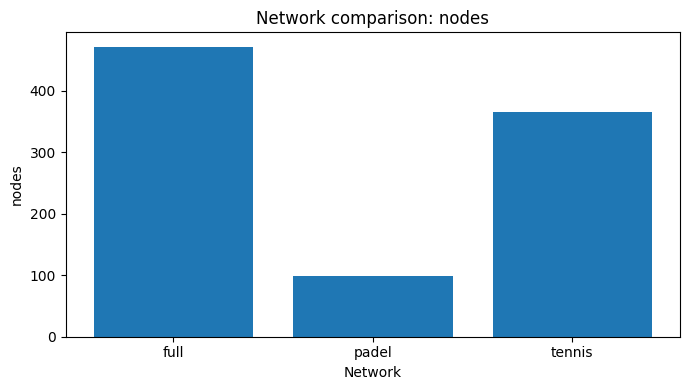

Saved: padel_vs_tennis_bluesky_network/figures/network_comparison_nodes.png


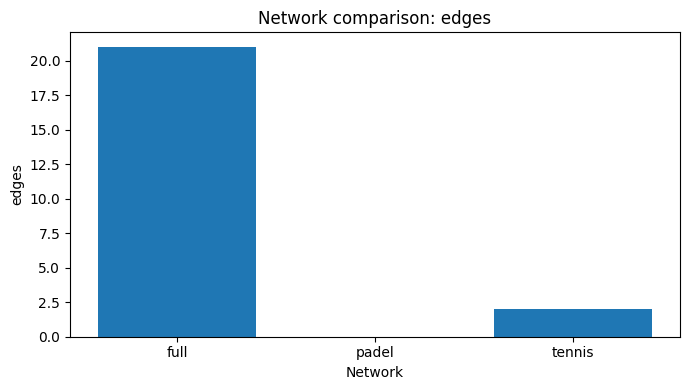

Saved: padel_vs_tennis_bluesky_network/figures/network_comparison_edges.png


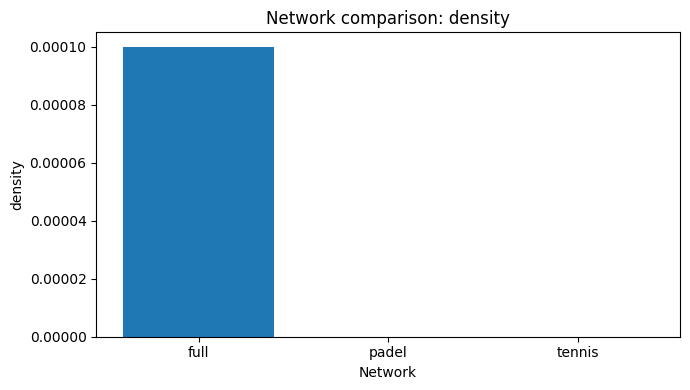

Saved: padel_vs_tennis_bluesky_network/figures/network_comparison_density.png


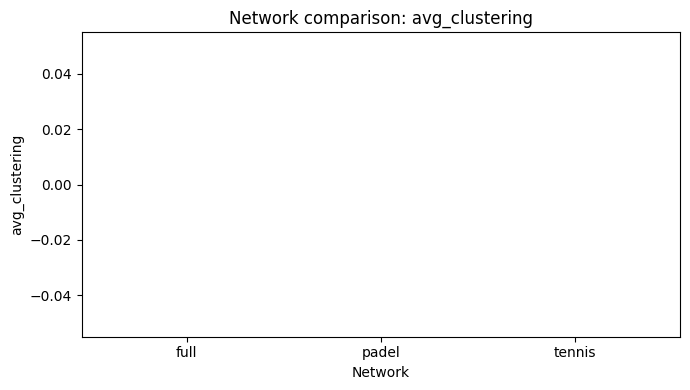

Saved: padel_vs_tennis_bluesky_network/figures/network_comparison_avg_clustering.png


In [ ]:

metrics_to_plot = ["nodes", "edges", "density", "avg_clustering"]
for metric in metrics_to_plot:
    plt.figure(figsize=(7, 4))
    plt.bar(stats_df["network"], stats_df[metric])
    plt.title(f"Network comparison: {metric}")
    plt.xlabel("Network")
    plt.ylabel(metric)
    plt.tight_layout()
    path = FIG_DIR / f"network_comparison_{metric}.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

## 5. Centrality analysis

Centrality measures are used to identify important users:

- **In-degree centrality:** users receiving many mentions; useful as an attention indicator.
- **Out-degree centrality:** users mentioning many others; useful as an activity indicator.
- **Betweenness centrality:** users lying on many shortest paths; useful for bridge detection.
- **PageRank:** users connected to other important users; useful as an influence indicator.

The final interpretation should not rely on one measure only. In social networks, different centrality measures capture different kinds of importance.

In [ ]:

def compute_centralities(graph):
    if graph.number_of_nodes() == 0:
        return pd.DataFrame()

    n = graph.number_of_nodes()

    degree_cent = nx.degree_centrality(graph)
    in_degree_cent = nx.in_degree_centrality(graph) if graph.is_directed() else degree_cent
    out_degree_cent = nx.out_degree_centrality(graph) if graph.is_directed() else degree_cent

    # Betweenness can be expensive. Approximate if graph is large.
    if n > 1000:
        k = min(300, n)
        betweenness = nx.betweenness_centrality(graph, k=k, weight="weight", seed=42)
    else:
        betweenness = nx.betweenness_centrality(graph, weight="weight")

    try:
        pagerank = nx.pagerank(graph, weight="weight")
    except Exception:
        pagerank = {node: 0 for node in graph.nodes()}

    rows = []
    for node in graph.nodes():
        rows.append({
            "node": node,
            "handle": graph.nodes[node].get("handle", node),
            "topic_type": graph.nodes[node].get("topic_type", "unknown"),
            "post_count": graph.nodes[node].get("post_count", 0),
            "engagement": graph.nodes[node].get("engagement", 0),
            "degree_centrality": degree_cent.get(node, 0),
            "in_degree_centrality": in_degree_cent.get(node, 0),
            "out_degree_centrality": out_degree_cent.get(node, 0),
            "betweenness_centrality": betweenness.get(node, 0),
            "pagerank": pagerank.get(node, 0),
            "in_degree": graph.in_degree(node) if graph.is_directed() else graph.degree(node),
            "out_degree": graph.out_degree(node) if graph.is_directed() else graph.degree(node),
        })
    return pd.DataFrame(rows)

centrality_full = compute_centralities(G)
centrality_padel = compute_centralities(G_padel)
centrality_tennis = compute_centralities(G_tennis)

centrality_full.to_csv(TABLE_DIR / "centrality_full.csv", index=False)
centrality_padel.to_csv(TABLE_DIR / "centrality_padel.csv", index=False)
centrality_tennis.to_csv(TABLE_DIR / "centrality_tennis.csv", index=False)

print("Centrality tables saved in:", TABLE_DIR)

Centrality tables saved in: padel_vs_tennis_bluesky_network/tables


In [ ]:

def top_users(df, metric, n=10):
    if df.empty or metric not in df.columns:
        return pd.DataFrame()
    return df.sort_values(metric, ascending=False).head(n)[
        ["handle", "topic_type", "post_count", "engagement", "in_degree", "out_degree", metric]
    ]

print("Top full-network users by PageRank")
display(top_users(centrality_full, "pagerank"))

print("Top padel users by PageRank")
display(top_users(centrality_padel, "pagerank"))

print("Top tennis users by PageRank")
display(top_users(centrality_tennis, "pagerank"))

print("Top bridge candidates by betweenness centrality")
display(top_users(centrality_full, "betweenness_centrality"))

Top full-network users by PageRank


,handle,topic_type,post_count,engagement,in_degree,out_degree,pagerank
453,did:plc:krni4bugnyot7ycymbx76i2r,mentioned_only,0,0,2,0,0.006177
312,tennistourtalk.bsky.social,tennis_only,3,1,1,1,0.003812
460,did:plc:rji2msf4lkscvud7w3potnk6,mentioned_only,0,0,1,0,0.003812
461,did:plc:lutusp5rz27fifqljtd3iyno,mentioned_only,0,0,1,0,0.003812
462,did:plc:azsiq6a5plbpa7ekw7pdrnum,mentioned_only,0,0,1,0,0.003812
463,did:plc:fr753mzicrykmvbuytq5ok4c,mentioned_only,0,0,1,0,0.003812
466,did:plc:hzcewbkoj4bxqtvdecivbptr,mentioned_only,0,0,1,0,0.003812
467,did:plc:yyiyccuveoyqshnhgk6fd2vp,mentioned_only,0,0,1,0,0.003812
468,did:plc:mzjx7ogv4bbk36axsbtskqnq,mentioned_only,0,0,1,0,0.003812
469,did:plc:vovinwhtulbsx4mwfw26r5ni,mentioned_only,0,0,1,0,0.003812


Top padel users by PageRank


,handle,topic_type,post_count,engagement,in_degree,out_degree,pagerank
0,kallimakhos.bsky.social,padel_only,1,0,0,0,0.010204
1,newsmonkey.bsky.social,both,3,0,0,0,0.010204
2,asianewstoday.bsky.social,both,2,0,0,0,0.010204
3,johnwimperis.bsky.social,padel_only,1,2,0,0,0.010204
4,everton.toffeetvefc.com,padel_only,1,2,0,0,0.010204
5,premierpadeltour.bsky.social,padel_only,2,4,0,0,0.010204
6,internazionaliditalia.stadio.top,padel_only,1,1,0,0,0.010204
7,stefanobornia.bsky.social,both,4,5,0,0,0.010204
8,markgoodrich.bsky.social,padel_only,1,1,0,0,0.010204
9,the5krunner.bsky.social,padel_only,1,2,0,0,0.010204


Top tennis users by PageRank


,handle,topic_type,post_count,engagement,in_degree,out_degree,pagerank
224,tennistourtalk.bsky.social,tennis_only,3,1,1,0,0.005045
259,atptour.stadio.top,tennis_only,5,32,1,0,0.005045
248,chieftabi.bsky.social,tennis_only,1,17,0,0,0.002727
247,zettawire.com,tennis_only,2,2,0,0,0.002727
246,matts-bluesky.bsky.social,tennis_only,1,0,0,0,0.002727
245,easterneye.bsky.social,tennis_only,1,0,0,0,0.002727
244,qprreport.bsky.social,tennis_only,1,1,0,0,0.002727
243,icshc.bsky.social,tennis_only,1,0,0,0,0.002727
242,snowydayuk.bsky.social,tennis_only,4,1,0,0,0.002727
241,mertontv.bsky.social,tennis_only,1,1,0,0,0.002727


Top bridge candidates by betweenness centrality


,handle,topic_type,post_count,engagement,in_degree,out_degree,betweenness_centrality
312,tennistourtalk.bsky.social,tennis_only,3,1,1,1,0.000005
322,bssh.bsky.social,tennis_only,1,0,0,0,0.000000
321,bringyourbaby.bsky.social,tennis_only,1,0,0,0,0.000000
320,proset90s.bsky.social,tennis_only,1,1,0,0,0.000000
319,cinquewnews.bsky.social,tennis_only,1,10,0,0,0.000000
318,postboxmap.bsky.social,tennis_only,1,3,0,0,0.000000
317,pitch-mag.bsky.social,tennis_only,1,0,0,0,0.000000
316,rtkrum.bsky.social,tennis_only,1,0,0,1,0.000000
315,strictlysports.bsky.social,tennis_only,1,1,0,0,0.000000
314,lpoolmike.bsky.social,tennis_only,1,2,0,0,0.000000


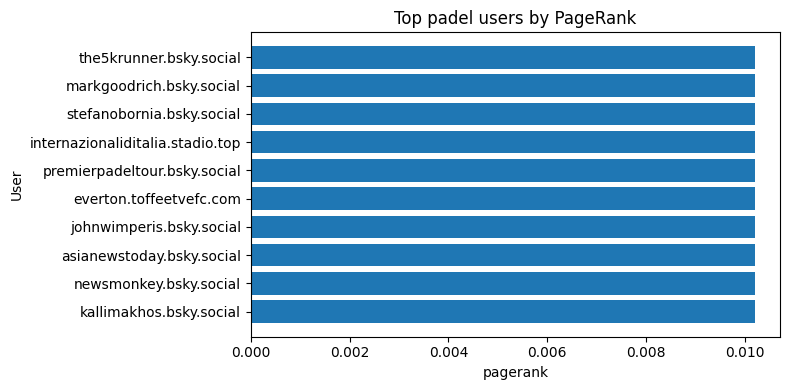

Saved: padel_vs_tennis_bluesky_network/figures/top_padel_pagerank.png


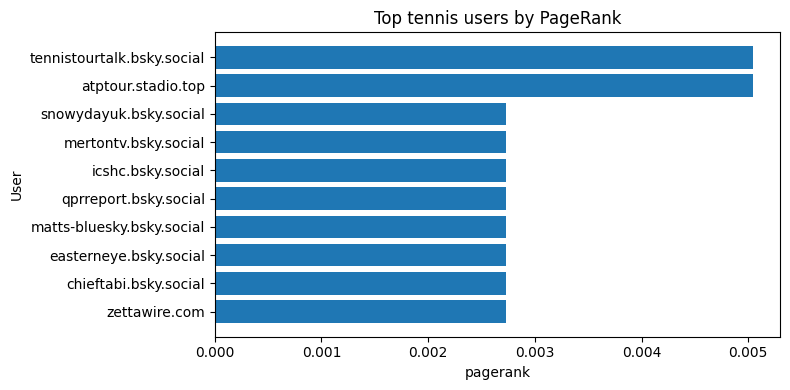

Saved: padel_vs_tennis_bluesky_network/figures/top_tennis_pagerank.png


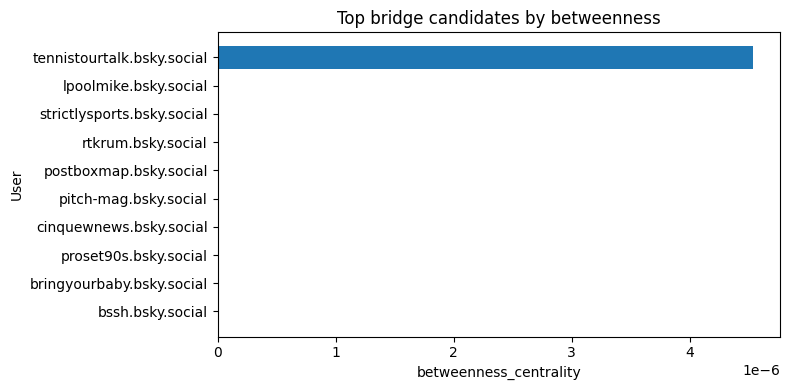

Saved: padel_vs_tennis_bluesky_network/figures/top_betweenness_bridge_candidates.png


In [ ]:

def plot_top_centrality(df, metric, title, filename, n=10):
    if df.empty or metric not in df.columns:
        print("No data for", title)
        return
    top = df.sort_values(metric, ascending=False).head(n).copy()
    top = top.sort_values(metric, ascending=True)
    labels = top["handle"].astype(str)

    plt.figure(figsize=(8, max(4, 0.4 * len(top))))
    plt.barh(labels, top[metric])
    plt.title(title)
    plt.xlabel(metric)
    plt.ylabel("User")
    plt.tight_layout()
    path = FIG_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

plot_top_centrality(centrality_padel, "pagerank", "Top padel users by PageRank", "top_padel_pagerank.png")
plot_top_centrality(centrality_tennis, "pagerank", "Top tennis users by PageRank", "top_tennis_pagerank.png")
plot_top_centrality(centrality_full, "betweenness_centrality", "Top bridge candidates by betweenness", "top_betweenness_bridge_candidates.png")

## 6. Community detection

Community detection is performed on the undirected version of the mention network. This is common when the goal is to detect groups of users that are densely connected, regardless of interaction direction.

The primary method is **Louvain community detection**, because it optimizes modularity and is appropriate for medium/large social graphs.

The key outputs are:

- detected community label for each user;
- number of communities;
- modularity score;
- cross-tabulation between detected communities and topic type.

Interpretation:

- high modularity suggests strong separation between communities;
- communities dominated by either `padel_only` or `tennis_only` suggest topic separation;
- mixed communities or many `both` users suggest overlap.

In [ ]:

def detect_communities_louvain(graph):
    """Detect communities and return node->community plus modularity."""
    if graph.number_of_nodes() == 0:
        return {}, 0

    UG = graph.to_undirected()
    UG.remove_edges_from(nx.selfloop_edges(UG))

    if UG.number_of_edges() == 0:
        communities = [{n} for n in UG.nodes()]
    else:
        try:
            # NetworkX Louvain, available in recent versions.
            communities = nx.community.louvain_communities(UG, weight="weight", seed=42)
        except Exception:
            try:
                # Fallback: python-louvain package.
                import community as community_louvain
                partition = community_louvain.best_partition(UG, weight="weight", random_state=42)
                comm_dict = defaultdict(set)
                for node, comm in partition.items():
                    comm_dict[comm].add(node)
                communities = list(comm_dict.values())
            except Exception:
                # Final fallback: greedy modularity.
                communities = list(nx.community.greedy_modularity_communities(UG, weight="weight"))

    node_to_comm = {}
    for i, comm in enumerate(communities):
        for node in comm:
            node_to_comm[node] = i

    try:
        modularity = nx.community.modularity(UG, communities, weight="weight")
    except Exception:
        modularity = np.nan

    return node_to_comm, modularity

node_to_comm, modularity = detect_communities_louvain(G)

community_df = pd.DataFrame([
    {
        "node": n,
        "handle": G.nodes[n].get("handle", n),
        "topic_type": G.nodes[n].get("topic_type", "unknown"),
        "community": node_to_comm.get(n, -1),
        "post_count": G.nodes[n].get("post_count", 0),
        "engagement": G.nodes[n].get("engagement", 0),
    }
    for n in G.nodes()
])

community_df.to_csv(TABLE_DIR / "communities_louvain.csv", index=False)

print("Number of detected communities:", community_df["community"].nunique())
print("Modularity:", round(modularity, 4) if not pd.isna(modularity) else modularity)
display(community_df.head())

Number of detected communities: 451
Modularity: 0.8246


,node,handle,topic_type,community,post_count,engagement
0,did:plc:wfnerm5c2emfy4iffllxqlr5,andreafriz.bsky.social,padel_only,0,1,0
1,did:plc:36zpq6cbx7jmsoce2hr624v4,siisar.bsky.social,padel_only,1,1,0
2,did:plc:4vmk2bts7rbvhlikpd5357ck,shymon84.bsky.social,padel_only,2,1,2
3,did:plc:eaxssnsscqcqspj7h4oeuxfj,pistacloud.bsky.social,padel_only,3,116,1
4,did:plc:2htr6vzopp6mejep7qcpszru,reporterre.net,padel_only,4,1,27


In [ ]:


community_sizes = community_df["community"].value_counts().sort_values(ascending=False).rename_axis("community").reset_index(name="size")
community_composition = pd.crosstab(community_df["community"], community_df["topic_type"])
community_composition["total"] = community_composition.sum(axis=1)
community_composition = community_composition.sort_values("total", ascending=False)

community_sizes.to_csv(TABLE_DIR / "community_sizes.csv", index=False)
community_composition.to_csv(TABLE_DIR / "community_composition_by_topic_type.csv")

print("Largest communities")
display(community_sizes.head(10))

print("Community composition by topic type")
display(community_composition.head(10))

Largest communities


,community,size
0,435,5
1,249,3
2,448,3
3,443,2
4,292,2
5,312,2
6,325,2
7,445,2
8,444,2
9,450,2


Community composition by topic type


topic_type,both,mentioned_only,padel_only,tennis_only,total
community,,,,,
435,0,4,0,1,5
249,0,1,0,2,3
448,0,2,1,0,3
443,0,1,1,0,2
444,0,1,0,1,2
445,0,1,0,1,2
446,0,1,0,1,2
447,0,1,0,1,2
449,0,1,0,1,2


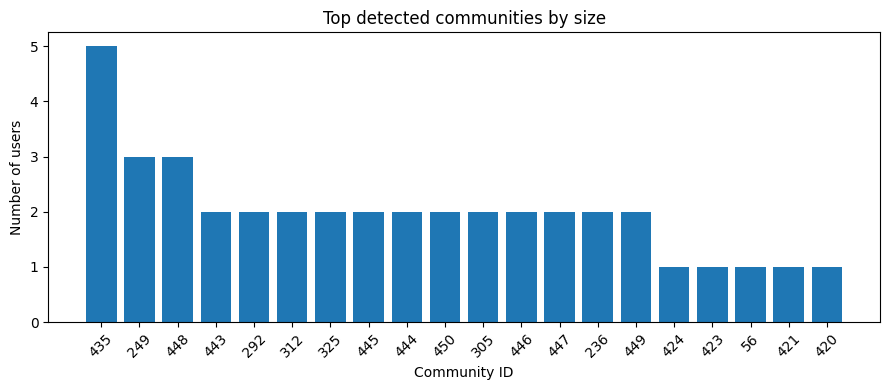

Saved: padel_vs_tennis_bluesky_network/figures/community_sizes.png


In [ ]:


plt.figure(figsize=(9, 4))
plot_df = community_sizes.head(20).copy()
plt.bar(plot_df["community"].astype(str), plot_df["size"])
plt.title("Top detected communities by size")
plt.xlabel("Community ID")
plt.ylabel("Number of users")
plt.xticks(rotation=45)
plt.tight_layout()
path = FIG_DIR / "community_sizes.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)

## 7. Bridge-user detection

Bridge users are defined as users that connect padel and tennis discussions. This notebook identifies them using three complementary criteria:

1. **Topic overlap:** the user appears in both padel and tennis datasets.
2. **Structural brokerage:** the user has high betweenness centrality.
3. **Cross-topic connections:** the user has connections to users from both topic groups.

A simple bridge score is computed as:

\[
\text{bridge score} = (1 + \text{padel connections}) \times (1 + \text{tennis connections}) \times (1 + \text{betweenness centrality})
\]

The score is not a universal metric; it is an operational definition designed for this project.

In [ ]:

# Topic type lookup for nodes.
topic_type_lookup = {n: G.nodes[n].get("topic_type", "unknown") for n in G.nodes()}

# For mentioned-only nodes, infer neighborhood topic exposure where possible.
def neighbor_topic_counts(graph, node):
    neighbors = set(graph.predecessors(node)) | set(graph.successors(node)) if graph.is_directed() else set(graph.neighbors(node))
    padel_count = 0
    tennis_count = 0
    both_count = 0
    for nb in neighbors:
        t = topic_type_lookup.get(nb, "unknown")
        if t == "padel_only":
            padel_count += 1
        elif t == "tennis_only":
            tennis_count += 1
        elif t == "both":
            both_count += 1
            padel_count += 1
            tennis_count += 1
    return padel_count, tennis_count, both_count

betweenness_map = dict(zip(centrality_full["node"], centrality_full["betweenness_centrality"])) if not centrality_full.empty else {}
pagerank_map = dict(zip(centrality_full["node"], centrality_full["pagerank"])) if not centrality_full.empty else {}

bridge_rows = []
for node in G.nodes():
    padel_conn, tennis_conn, both_conn = neighbor_topic_counts(G, node)
    topic_type = G.nodes[node].get("topic_type", "unknown")
    appears_in_both = 1 if topic_type == "both" else 0
    bet = betweenness_map.get(node, 0)
    pr = pagerank_map.get(node, 0)

    bridge_score = (1 + padel_conn) * (1 + tennis_conn) * (1 + bet) * (1 + appears_in_both)

    bridge_rows.append({
        "node": node,
        "handle": G.nodes[node].get("handle", node),
        "topic_type": topic_type,
        "padel_connections": padel_conn,
        "tennis_connections": tennis_conn,
        "both_neighbor_connections": both_conn,
        "appears_in_both_topics": appears_in_both,
        "betweenness_centrality": bet,
        "pagerank": pr,
        "bridge_score": bridge_score,
        "post_count": G.nodes[node].get("post_count", 0),
        "engagement": G.nodes[node].get("engagement", 0),
    })

bridge_df = pd.DataFrame(bridge_rows).sort_values("bridge_score", ascending=False)
bridge_df.to_csv(TABLE_DIR / "bridge_users.csv", index=False)

display(bridge_df.head(15))

,node,handle,topic_type,padel_connections,tennis_connections,both_neighbor_connections,appears_in_both_topics,betweenness_centrality,pagerank,bridge_score,post_count,engagement
453,did:plc:krni4bugnyot7ycymbx76i2r,did:plc:krni4bugnyot7ycymbx76i2r,mentioned_only,0,2,0,0,0.000000,0.006177,3.000000,0,0
312,did:plc:q26wuyujp2av5axczdwgzr3g,tennistourtalk.bsky.social,tennis_only,0,1,0,0,0.000005,0.003812,2.000009,3,1
466,did:plc:hzcewbkoj4bxqtvdecivbptr,did:plc:hzcewbkoj4bxqtvdecivbptr,mentioned_only,0,1,0,0,0.000000,0.003812,2.000000,0,0
465,did:plc:p7gdpofkiswapwrhfos7nqqd,did:plc:p7gdpofkiswapwrhfos7nqqd,mentioned_only,1,0,0,0,0.000000,0.002936,2.000000,0,0
464,did:plc:ep7nkgq25dcoufjkhywtx6uv,did:plc:ep7nkgq25dcoufjkhywtx6uv,mentioned_only,1,0,0,0,0.000000,0.002936,2.000000,0,0
463,did:plc:fr753mzicrykmvbuytq5ok4c,did:plc:fr753mzicrykmvbuytq5ok4c,mentioned_only,0,1,0,0,0.000000,0.003812,2.000000,0,0
462,did:plc:azsiq6a5plbpa7ekw7pdrnum,did:plc:azsiq6a5plbpa7ekw7pdrnum,mentioned_only,0,1,0,0,0.000000,0.003812,2.000000,0,0
461,did:plc:lutusp5rz27fifqljtd3iyno,did:plc:lutusp5rz27fifqljtd3iyno,mentioned_only,0,1,0,0,0.000000,0.003812,2.000000,0,0
28,did:plc:hslirr7h6d7livppaxty435b,newsen.bsky.social,both,0,0,0,1,0.000000,0.002060,2.000000,7,3
460,did:plc:rji2msf4lkscvud7w3potnk6,did:plc:rji2msf4lkscvud7w3potnk6,mentioned_only,0,1,0,0,0.000000,0.003812,2.000000,0,0


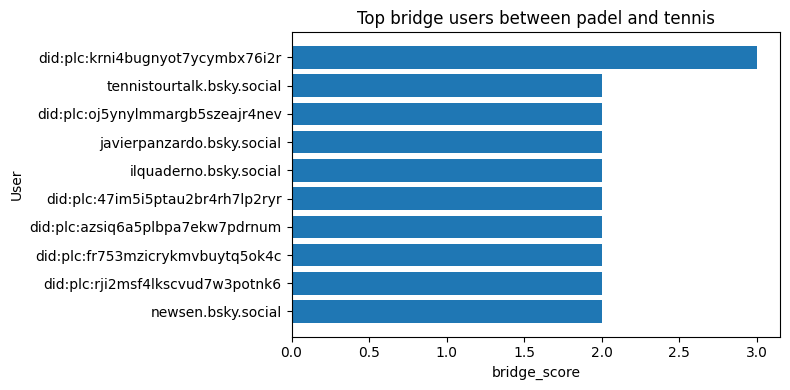

Saved: padel_vs_tennis_bluesky_network/figures/top_bridge_users.png


In [ ]:

plot_top_centrality(
    bridge_df.rename(columns={"bridge_score": "bridge_score"}),
    "bridge_score",
    "Top bridge users between padel and tennis",
    "top_bridge_users.png",
    n=10,
)

## 8. Network visualization

Network visualizations are useful for presentation, but they should be interpreted carefully: layout algorithms are not statistical tests. The quantitative results above are more important.

The notebook creates two visualizations:

1. the full network colored by user topic type;
2. the full network colored by detected Louvain community.

For very large graphs, the visualization uses a simplified subgraph containing the largest connected component and/or top-degree nodes.

In [ ]:

def select_visual_subgraph(graph, max_nodes=300):
    """Select a readable subgraph for visualization."""
    if graph.number_of_nodes() <= max_nodes:
        return graph.copy()

    UG = graph.to_undirected()
    largest_cc = max(nx.connected_components(UG), key=len)
    H = graph.subgraph(largest_cc).copy()

    if H.number_of_nodes() > max_nodes:
        top_nodes = sorted(H.degree, key=lambda x: x[1], reverse=True)[:max_nodes]
        top_nodes = [n for n, _ in top_nodes]
        H = H.subgraph(top_nodes).copy()
    return H


def color_by_topic_type(topic_type):
    # Colors intentionally simple and documented for interpretability.
    mapping = {
        "padel_only": "tab:orange",
        "tennis_only": "tab:blue",
        "both": "tab:purple",
        "mentioned_only": "lightgray",
        "unknown": "gray",
    }
    return mapping.get(topic_type, "gray")


def plot_network_by_topic(graph, filename="network_by_topic_type.png", max_nodes=300):
    H = select_visual_subgraph(graph, max_nodes=max_nodes)
    if H.number_of_nodes() == 0:
        print("Empty graph.")
        return

    pos = nx.spring_layout(H.to_undirected(), seed=42, k=None)
    node_colors = [color_by_topic_type(H.nodes[n].get("topic_type", "unknown")) for n in H.nodes()]
    node_sizes = [40 + 80 * math.log1p(H.degree(n)) for n in H.nodes()]

    plt.figure(figsize=(11, 9))
    nx.draw_networkx_edges(H, pos, alpha=0.15, width=0.6, arrows=False)
    nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, linewidths=0.2)

    # Label only the most connected nodes.
    top_label_nodes = [n for n, _ in sorted(H.degree, key=lambda x: x[1], reverse=True)[:12]]
    labels = {n: H.nodes[n].get("handle", str(n)) for n in top_label_nodes}
    nx.draw_networkx_labels(H, pos, labels=labels, font_size=8)

    plt.title("Padel vs Tennis mention network colored by topic type")
    plt.axis("off")
    path = FIG_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


def plot_network_by_community(graph, node_to_comm, filename="network_by_louvain_community.png", max_nodes=300):
    H = select_visual_subgraph(graph, max_nodes=max_nodes)
    if H.number_of_nodes() == 0:
        print("Empty graph.")
        return

    pos = nx.spring_layout(H.to_undirected(), seed=42)
    communities = [node_to_comm.get(n, -1) for n in H.nodes()]
    node_sizes = [40 + 80 * math.log1p(H.degree(n)) for n in H.nodes()]

    plt.figure(figsize=(11, 9))
    nx.draw_networkx_edges(H, pos, alpha=0.15, width=0.6, arrows=False)
    nx.draw_networkx_nodes(H, pos, node_color=communities, cmap=plt.cm.tab20, node_size=node_sizes, alpha=0.9, linewidths=0.2)

    top_label_nodes = [n for n, _ in sorted(H.degree, key=lambda x: x[1], reverse=True)[:12]]
    labels = {n: H.nodes[n].get("handle", str(n)) for n in top_label_nodes}
    nx.draw_networkx_labels(H, pos, labels=labels, font_size=8)

    plt.title("Mention network colored by Louvain community")
    plt.axis("off")
    path = FIG_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

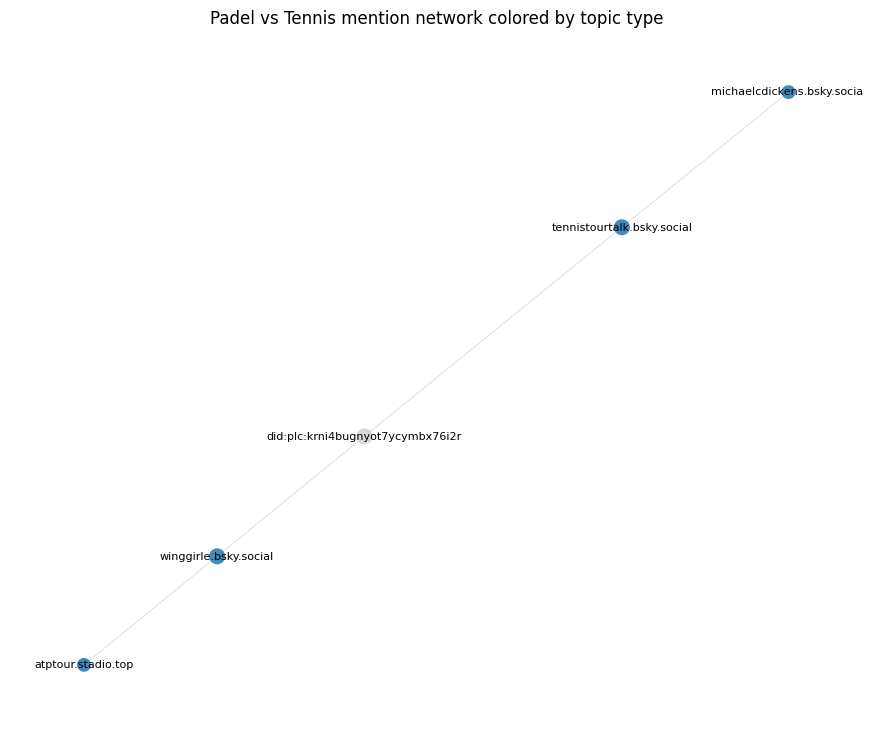

Saved: padel_vs_tennis_bluesky_network/figures/network_by_topic_type.png


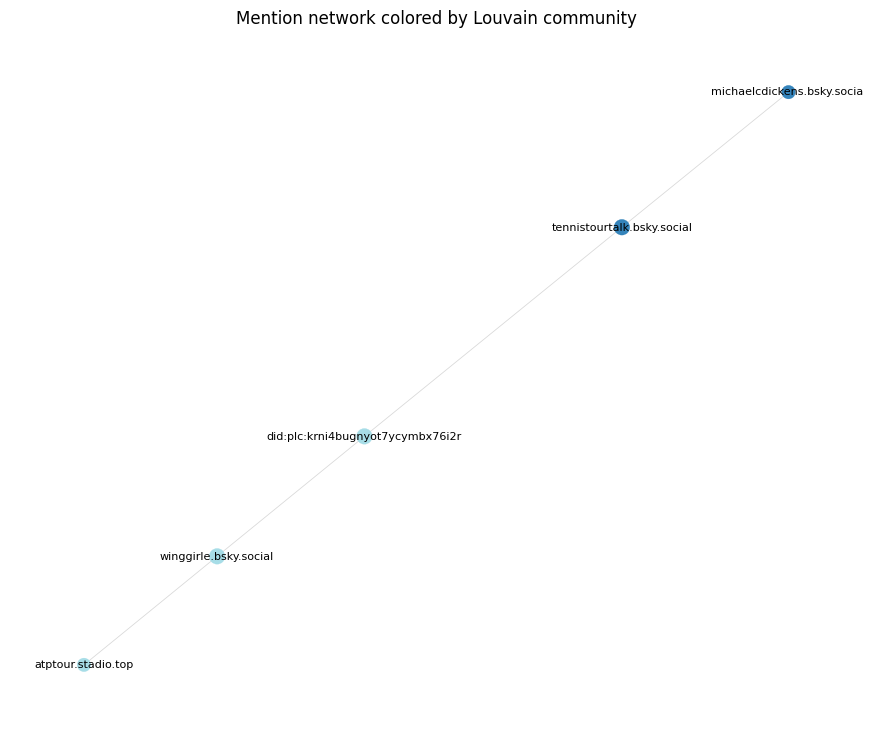

Saved: padel_vs_tennis_bluesky_network/figures/network_by_louvain_community.png


In [ ]:

plot_network_by_topic(G, max_nodes=300)
plot_network_by_community(G, node_to_comm, max_nodes=300)

## 10. Automatic result summary for the report

The next cell prints a compact interpretation template using the actual computed values. You should manually refine the wording after inspecting the visualizations and the top-user tables.

In [ ]:


n_posts = len(clean_df)
n_authors = clean_df["author_did"].nunique()
n_padel = int((clean_df["topic_label"] == "padel").sum())
n_tennis = int((clean_df["topic_label"] == "tennis").sum())
n_both = len(both_authors)
share_both = n_both / max(1, len(padel_authors | tennis_authors))

largest_comm = int(community_sizes.iloc[0]["size"]) if len(community_sizes) else 0
n_communities = community_df["community"].nunique() if not community_df.empty else 0

print("RESULT SUMMARY")
print("-" * 70)
print(f"The dataset contains {n_posts} posts written by {n_authors} unique authors.")
print(f"Padel posts: {n_padel}; tennis posts: {n_tennis}.")
print(f"Authors appearing in both topic datasets: {n_both} ({share_both:.2%} of authors active in at least one topic).")
print(f"The mention network contains {G.number_of_nodes()} nodes and {G.number_of_edges()} weighted directed edges.")
print(f"Louvain detected {n_communities} communities, with modularity = {modularity:.4f}.")
print(f"The largest detected community contains {largest_comm} users.")

if not bridge_df.empty:
    top_bridge = bridge_df.iloc[0]
    print(f"The top bridge candidate is {top_bridge['handle']} with bridge_score = {top_bridge['bridge_score']:.4f}.")

print("\nSuggested interpretation questions:")
print("1. Are the largest communities dominated by padel_only or tennis_only users?")
print("2. Are the top PageRank users official accounts, media accounts, clubs, athletes, or ordinary fans?")
print("3. Are bridge users mainly sports media/general racket-sport accounts, or normal users interested in both sports?")
print("4. Does the network evidence agree with the content-analysis results from sentiment, NER, and hashtags?")

RESULT SUMMARY
----------------------------------------------------------------------
The dataset contains 1231 posts written by 453 unique authors.
Padel posts: 300; tennis posts: 931.
Authors appearing in both topic datasets: 10 (2.21% of authors active in at least one topic).
The mention network contains 471 nodes and 21 weighted directed edges.
Louvain detected 451 communities, with modularity = 0.8246.
The largest detected community contains 5 users.
The top bridge candidate is did:plc:krni4bugnyot7ycymbx76i2r with bridge_score = 3.0000.

Suggested interpretation questions:
1. Are the largest communities dominated by padel_only or tennis_only users?
2. Are the top PageRank users official accounts, media accounts, clubs, athletes, or ordinary fans?
3. Are bridge users mainly sports media/general racket-sport accounts, or normal users interested in both sports?
4. Does the network evidence agree with the content-analysis results from sentiment, NER, and hashtags?


# **CONTENT ANALYSIS:**

In [ ]:
"""
!pip -q install afinn nrclex wordcloud
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 78.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import string
from afinn import Afinn
from nrclex import NRCLex
from wordcloud import WordCloud
import spacy

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords

print("Content analysis libraries loaded.")

Content analysis libraries loaded.


## Text Preprocessing

Before applying any analysis, raw post text needs to be cleaned and tokenized.
We use NLTK's `TweetTokenizer`, which is specifically designed for social media text and handles hashtags, mentions, and emoticons correctly.
Stopwords, punctuation, URLs, and the topic keywords themselves ("padel", "tennis") are removed since they appear in virtually every post and carry no discriminative information.

In [ ]:

tokenizer = TweetTokenizer(reduce_len=True)

stop = set(stopwords.words('english'))
stop.update([
    'http', 'https', 'co', '...', '@user', 'rt', 'via',
    'padel', 'tennis',
])
punctuation = set(string.punctuation)

def preprocess(text):
    if not isinstance(text, str):
        return []
    tokens = tokenizer.tokenize(text)
    tokens = [t.lower() for t in tokens]
    tokens = [t for t in tokens if t not in stop]
    tokens = [t for t in tokens if t not in punctuation]
    tokens = [t for t in tokens if len(t) > 1]
    tokens = [t for t in tokens if not t.startswith('http')]
    return tokens

clean_df['tokens'] = clean_df['text'].apply(preprocess)
print("Preprocessing done.")
print("Example:", clean_df['text'].iloc[0])
print("Tokens: ", clean_df['tokens'].iloc[0])

Preprocessing done.
Example: Ma quelli del padel stanno nel loro gabbiotto e non rompono il cazzo a nessuno  sul bagnasciuga!!  😅
Tokens:  ['quelli', 'del', 'stanno', 'nel', 'loro', 'gabbiotto', 'non', 'rompono', 'il', 'cazzo', 'nessuno', 'sul', 'bagnasciuga']


## Sentiment Analysis

We use the AFINN lexicon to assign a sentiment score to each post.
AFINN maps individual words to integer scores ranging from -5 (very negative) to +5 (very positive); the total score of a post is the sum of its words' scores.
Posts are then labeled as positive (score > 0), negative (score < 0), or neutral (score = 0).
We compare the sentiment distributions of the two communities to understand whether padel and tennis generate different emotional responses on Bluesky.

In [ ]:

afinn = Afinn()

clean_df['sentiment_score'] = clean_df['text'].apply(lambda t: afinn.score(t))
clean_df['sentiment_label'] = clean_df['sentiment_score'].apply(
    lambda s: 'positive' if s > 0 else ('negative' if s < 0 else 'neutral')
)

print("Sentiment distribution by topic:")
display(
    clean_df.groupby(['topic_label', 'sentiment_label'])
    .size()
    .unstack(fill_value=0)
)

Sentiment distribution by topic:


sentiment_label,negative,neutral,positive
topic_label,,,
padel,19,227,54
tennis,128,430,373


sentiment_label  positive  neutral  negative
topic_label                                 
padel                  54      227        19
tennis                373      430       128


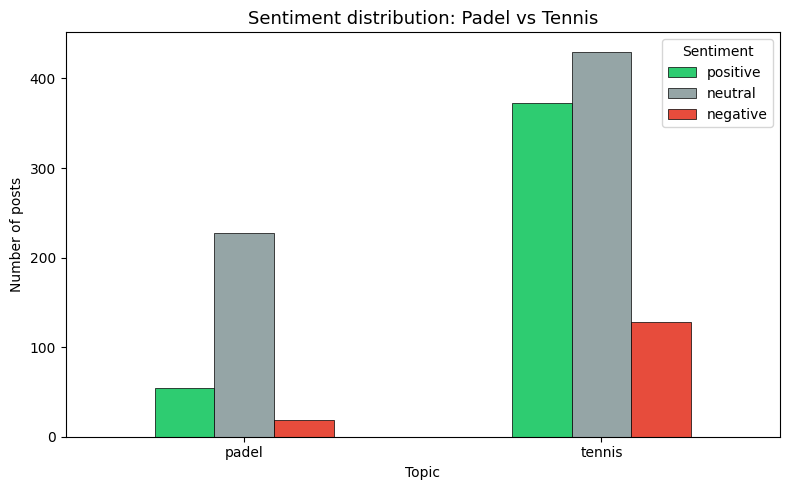

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts = (
    clean_df.groupby(['topic_label', 'sentiment_label'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['positive', 'neutral', 'negative'], fill_value=0)
)

print(sentiment_counts)  # controlla che ci siano dati

fig, ax = plt.subplots(figsize=(8, 5))
sentiment_counts.plot(
    kind='bar',
    ax=ax,
    color=['#2ecc71', '#95a5a6', '#e74c3c'],
    edgecolor='black',
    linewidth=0.5,
)
ax.set_title('Sentiment distribution: Padel vs Tennis', fontsize=13)
ax.set_xlabel('Topic')
ax.set_ylabel('Number of posts')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Sentiment')
plt.tight_layout()
plt.show()

## Emotion Analysis

Beyond positive/negative polarity, we analyze the emotional content of posts using the NRC Emotion Lexicon.
NRC associates words with 8 basic emotions: anger, anticipation, disgust, fear, joy, sadness, surprise, and trust.
For each post, we compute the normalized frequency of each emotion and then average across all posts per topic.
This allows us to compare the emotional profiles of the padel and tennis communities in greater depth than sentiment alone.

In [ ]:

EMOTIONS = ['anger', 'anticipation', 'disgust', 'fear',
            'joy', 'sadness', 'surprise', 'trust']

!pip -q install nltk
import nltk
nltk.download('opinion_lexicon', quiet=True)

#NRC
import urllib.request
import csv
from collections import defaultdict

NRC_URL = "https://raw.githubusercontent.com/dinbav/LeXmo/master/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"

nrc_lexicon = defaultdict(dict)
try:
    response = urllib.request.urlopen(NRC_URL)
    lines = response.read().decode('utf-8').splitlines()
    for line in lines:
        parts = line.strip().split('\t')
        if len(parts) == 3:
            word, emotion, value = parts
            if emotion in EMOTIONS:
                nrc_lexicon[word][emotion] = int(value)
    print(f"Lexicon loaded: {len(nrc_lexicon)} words")
except Exception as e:
    print("Error loading lexicon:", e)

def get_emotion_scores(text):
    if not isinstance(text, str) or not text.strip():
        return {e: 0.0 for e in EMOTIONS}

    tokens = tokenizer.tokenize(text.lower())
    scores = {e: 0 for e in EMOTIONS}
    count = 0

    for token in tokens:
        if token in nrc_lexicon:
            for emotion in EMOTIONS:
                scores[emotion] += nrc_lexicon[token].get(emotion, 0)
            count += 1

    total = sum(scores.values())
    if total == 0:
        return {e: 0.0 for e in EMOTIONS}
    return {e: scores[e] / total for e in EMOTIONS}

emotion_records = clean_df['text'].apply(get_emotion_scores)
emotion_df_cols = pd.DataFrame(emotion_records.tolist())

# Remove old columns
clean_df = clean_df.drop(columns=[e for e in EMOTIONS if e in clean_df.columns], errors='ignore')
clean_df = pd.concat([clean_df, emotion_df_cols], axis=1)

emotion_by_topic = clean_df.groupby('topic_label')[EMOTIONS].mean()
display(emotion_by_topic.round(4))

Lexicon loaded: 14182 words
Computing emotions...


,anger,anticipation,disgust,fear,joy,sadness,surprise,trust
topic_label,,,,,,,,
padel,0.0246,0.0633,0.0086,0.0220,0.0339,0.0175,0.0187,0.0482
tennis,0.0747,0.1121,0.0300,0.0858,0.0568,0.0527,0.0465,0.1245


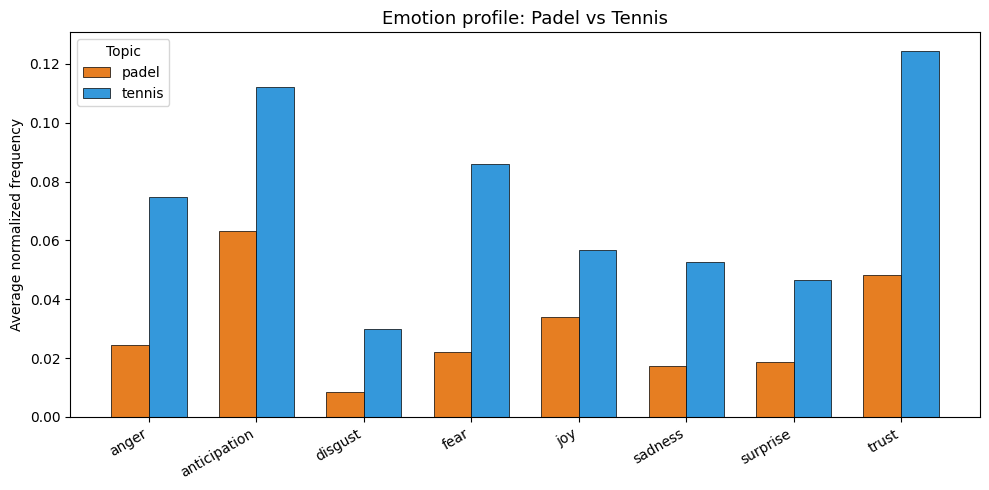

Saved: padel_vs_tennis_bluesky_network/figures/emotion_profile.png


In [ ]:
x = np.arange(len(EMOTIONS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
for i, (topic, color) in enumerate(zip(['padel', 'tennis'], ['#e67e22', '#3498db'])):
    if topic in emotion_by_topic.index:
        vals = emotion_by_topic.loc[topic, EMOTIONS].values
        ax.bar(x + i * width, vals, width, label=topic, color=color,
               edgecolor='black', linewidth=0.5)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(EMOTIONS, rotation=30, ha='right')
ax.set_title('Emotion profile: Padel vs Tennis', fontsize=13)
ax.set_ylabel('Average normalized frequency')
ax.legend(title='Topic')
plt.tight_layout()
path = FIG_DIR / 'emotion_profile.png'
plt.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", path)

## Named Entity Recognition (NER)

Named Entity Recognition allows us to identify the real-world entities most discussed in each community: athletes, tournaments, organizations, and locations.
We use spaCy's `en_core_web_sm` model to extract entities of type PERSON, ORG, GPE (countries/cities), EVENT, and LOC.
A cleaning step removes noisy extractions such as match scores, URLs, and overly long strings that spaCy misclassified as entities.
Comparing the top entities across topics reveals what and who each community focuses on.

In [ ]:

nlp = spacy.load('en_core_web_sm')
ENTITY_TYPES = ['PERSON', 'ORG', 'GPE','EVENT', 'LOC']
print("spaCy loaded!")

spaCy loaded!


In [ ]:
def clean_entity(text):
    """Remove noisy entities."""
    text = text.strip()
    # rimuovi entità troppo corte
    if len(text) <= 2:
        return None
    # rimuovi entità con numeri di score (es. "6/1 6/2")
    if re.search(r'\d/\d', text):
        return None
    # rimuovi entità troppo lunghe
    if len(text) > 40:
        return None
    # rimuovi URL
    if 'http' in text.lower():
        return None
    return text

def extract_entities_clean(text):
    if not isinstance(text, str) or not text.strip():
        return []
    doc = nlp(text)
    results = []
    for ent in doc.ents:
        if ent.label_ not in ENTITY_TYPES:
            continue
        cleaned = clean_entity(ent.text)
        if cleaned:
            results.append((cleaned, ent.label_))
    return results

def entity_counter(dataframe, topic, entity_type=None):
    subset = dataframe[dataframe['topic_label'] == topic]
    all_ents = [ent for ents in subset['entities'] for ent in ents]
    if entity_type:
        all_ents = [(txt, lbl) for txt, lbl in all_ents if lbl == entity_type]
    return Counter([txt for txt, lbl in all_ents])

print("Re-running NER with cleaning...")
clean_df['entities'] = clean_df['text'].apply(extract_entities_clean)

for topic in ['padel', 'tennis']:
    print(f"\nTop 10 entities — {topic.upper()}:")
    display(pd.DataFrame(entity_counter(clean_df, topic).most_common(10),
                         columns=['entity', 'count']))

Re-running NER with cleaning...

Top 10 entities — PADEL:


,entity,count
0,FIP SILVER MEDIOLANUM PADEL,116
1,G. Giacalone,29
2,PremierPadel,19
3,Tapia,8
4,London,4
5,Spain,4
6,Chingotto,4
7,Coello,4
8,Portugal,4
9,Lisbon,4



Top 10 entities — TENNIS:


,entity,count
0,Wimbledon,83
1,RolandGarros,61
2,Roland Garros,56
3,Paris,48
4,Serena Williams,47
5,Francia,39
6,Alcaraz,38
7,Cobolli,37
8,Alexander Zverev,35
9,el Court,30


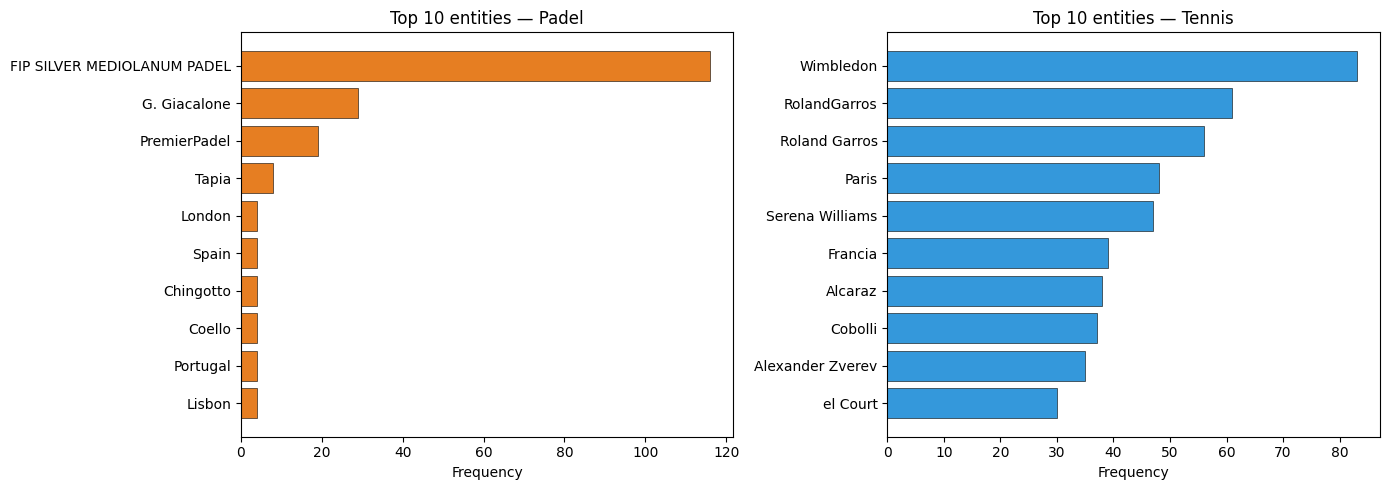

Saved: padel_vs_tennis_bluesky_network/figures/top_entities.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, topic, color in zip(axes, ['padel', 'tennis'], ['#e67e22', '#3498db']):
    cnt = entity_counter(clean_df, topic)
    top = cnt.most_common(10)
    if not top:
        ax.set_title(f'No entities for {topic}')
        continue
    labels, values = zip(*top)
    ax.barh(list(reversed(labels)), list(reversed(values)),
            color=color, edgecolor='black', linewidth=0.4)
    ax.set_title(f'Top 10 entities — {topic.capitalize()}', fontsize=12)
    ax.set_xlabel('Frequency')

plt.tight_layout()
path = FIG_DIR / 'top_entities.png'
plt.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", path)

## Word Clouds

Word clouds provide an immediate visual summary of the most frequent terms in each community's posts after preprocessing.
Word size is proportional to frequency. The two clouds use different color palettes (orange for padel, blue for tennis) to facilitate comparison.

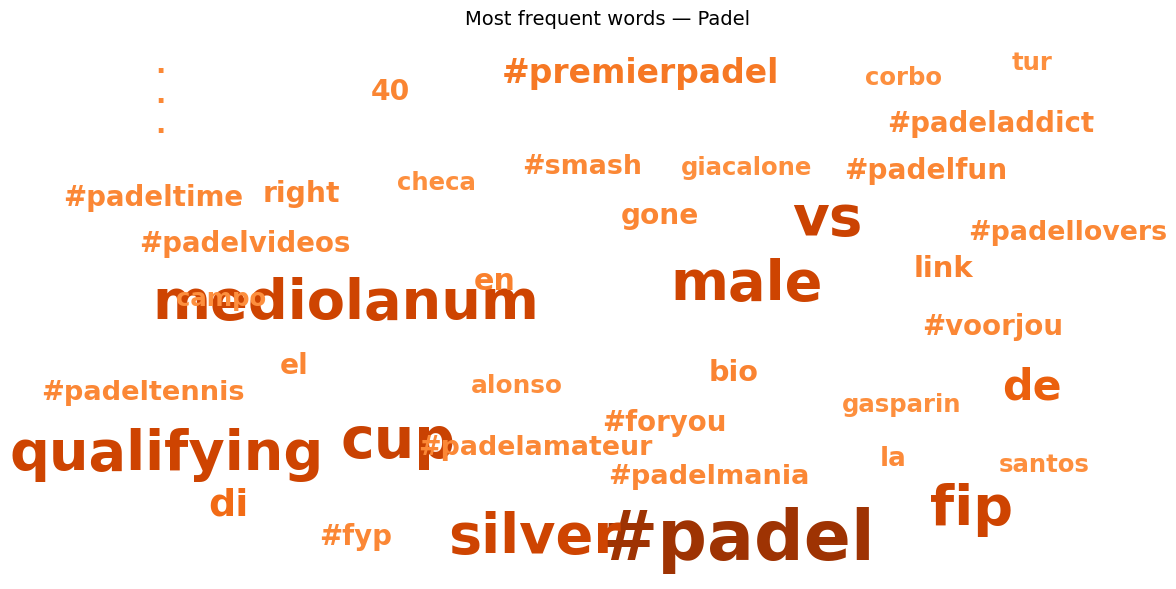

Saved: padel_vs_tennis_bluesky_network/figures/wordcloud_padel.png


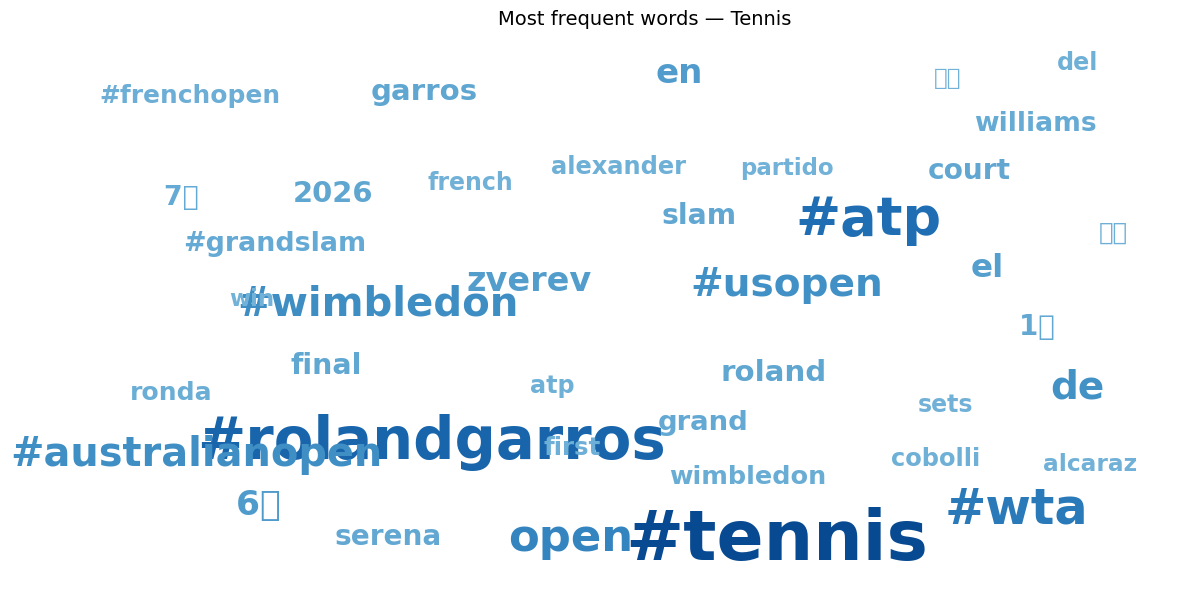

Saved: padel_vs_tennis_bluesky_network/figures/wordcloud_tennis.png


In [ ]:

import matplotlib.pyplot as plt
from collections import Counter
import random

def make_word_cloud_manual(dataframe, topic):
    subset = dataframe[dataframe['topic_label'] == topic]
    all_tokens = [t for tokens in subset['tokens'] for t in tokens]
    freq = Counter(all_tokens)
    if not freq:
        print(f"No tokens for {topic}")
        return

    top_words = freq.most_common(40)
    words, counts = zip(*top_words)
    max_count = max(counts)
    cmap = plt.cm.Oranges if topic == 'padel' else plt.cm.Blues

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('off')
    ax.set_title(f'Most frequent words — {topic.capitalize()}', fontsize=14)

    random.seed(42)
    used = []
    for word, count in zip(words, counts):
        size = 10 + 40 * (count / max_count)
        color = cmap(0.4 + 0.5 * (count / max_count))
        for _ in range(200):
            x = random.uniform(0.05, 0.95)
            y = random.uniform(0.05, 0.95)
            if not any(abs(x-px) < 0.12 and abs(y-py) < 0.08 for px, py in used):
                used.append((x, y))
                ax.text(x, y, word, fontsize=size, color=color,
                        ha='center', va='center',
                        transform=ax.transAxes, fontweight='bold')
                break

    plt.tight_layout()
    path = FIG_DIR / f'wordcloud_{topic}.png'
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

make_word_cloud_manual(clean_df, 'padel')
make_word_cloud_manual(clean_df, 'tennis')


#**Hashtag Frequency**

Hashtags are explicit topic markers chosen by users themselves, making them a strong signal of what each community wants to talk about.
We extract and count all hashtags from padel and tennis posts separately to identify the most prominent themes and events discussed in each community.
python



Top 10 hashtags — PADEL:


,hashtag,count
0,padel,152
1,premierpadel,53
2,padelfun,39
3,foryou,38
4,fyp,38
5,padeladdict,38
6,padeltime,38
7,padelvideos,38
8,voorjou,38
9,padelmania,37



Top 10 hashtags — TENNIS:


,hashtag,count
0,tennis,276
1,rolandgarros,219
2,atp,201
3,wta,177
4,wimbledon,131
5,australianopen,130
6,usopen,125
7,grandslam,64
8,frenchopen,55
9,paris,44


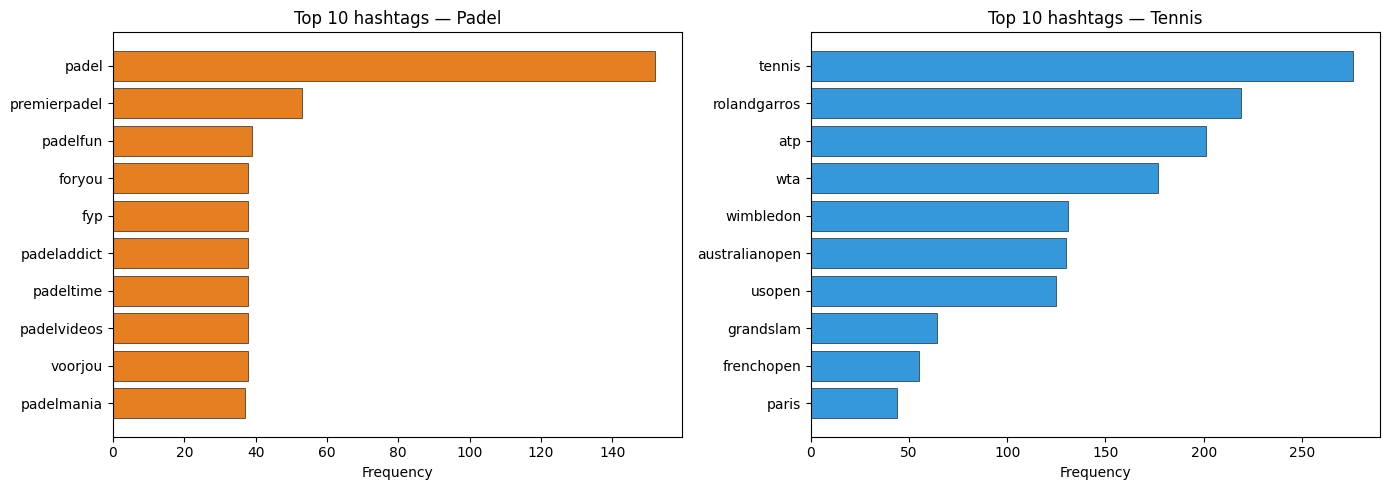

In [ ]:
from collections import Counter

def hashtag_counter(dataframe, topic):
    subset = dataframe[dataframe['topic_label'] == topic]
    all_tags = [tag.lower().strip('#') for tags in subset['hashtags'] for tag in tags if tag]
    return Counter(all_tags)

for topic in ['padel', 'tennis']:
    print(f"\nTop 10 hashtags — {topic.upper()}:")
    display(pd.DataFrame(hashtag_counter(clean_df, topic).most_common(10),
                         columns=['hashtag', 'count']))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, topic, color in zip(axes, ['padel', 'tennis'], ['#e67e22', '#3498db']):
    cnt = hashtag_counter(clean_df, topic)
    top = cnt.most_common(10)
    if not top:
        ax.set_title(f'No hashtags for {topic}')
        continue
    labels, values = zip(*top)
    ax.barh(list(reversed(labels)), list(reversed(values)),
            color=color, edgecolor='black', linewidth=0.4)
    ax.set_title(f'Top 10 hashtags — {topic.capitalize()}', fontsize=12)
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig(FIG_DIR / 'top_hashtags.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. hashtag co-occurrence network



Here, hashtags are nodes and two hashtags are connected if they appear in the same post. This helps identify shared vocabulary between padel and tennis discussions.

In [ ]:

hashtag_edges = Counter()
hashtag_topic_counter = defaultdict(Counter)

for _, row in clean_df.iterrows():
    tags = sorted(set([str(t).lower().strip("#") for t in row["hashtags"] if str(t).strip()]))
    topic = row["topic_label"]
    for tag in tags:
        hashtag_topic_counter[tag][topic] += 1
    for i in range(len(tags)):
        for j in range(i + 1, len(tags)):
            hashtag_edges[(tags[i], tags[j])] += 1

H_tags = nx.Graph()
for tag, counts in hashtag_topic_counter.items():
    dominant_topic = counts.most_common(1)[0][0] if counts else "unknown"
    H_tags.add_node(tag, total=sum(counts.values()), dominant_topic=dominant_topic, padel=counts.get("padel", 0), tennis=counts.get("tennis", 0))
for (a, b), w in hashtag_edges.items():
    H_tags.add_edge(a, b, weight=w)

hashtag_nodes_df = pd.DataFrame([
    {"hashtag": n, **data} for n, data in H_tags.nodes(data=True)
]).sort_values("total", ascending=False)

hashtag_nodes_df.to_csv(TABLE_DIR / "hashtag_nodes_optional.csv", index=False)

display(hashtag_nodes_df.head(20))
print("Hashtag co-occurrence graph:", H_tags.number_of_nodes(), "nodes,", H_tags.number_of_edges(), "edges")

,hashtag,total,dominant_topic,padel,tennis
32,tennis,282,tennis,6,276
432,rolandgarros,219,tennis,0,219
447,atp,201,tennis,0,201
368,wta,177,tennis,0,177
2,padel,152,padel,152,0
354,wimbledon,131,tennis,0,131
843,australianopen,130,tennis,0,130
441,usopen,125,tennis,0,125
466,grandslam,64,tennis,0,64
458,frenchopen,55,tennis,0,55


Hashtag co-occurrence graph: 1284 nodes, 7944 edges


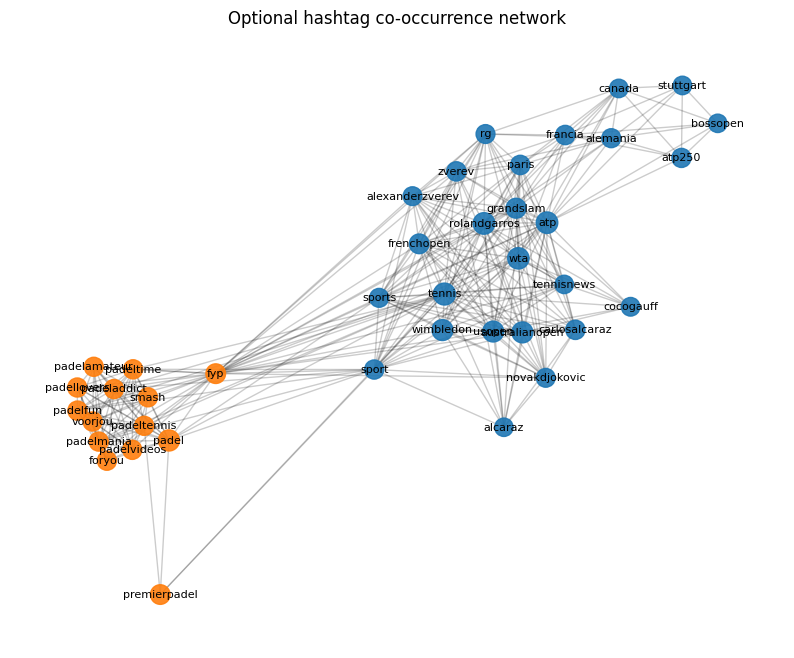

Saved: padel_vs_tennis_bluesky_network/figures/optional_hashtag_cooccurrence_network.png


In [ ]:

if H_tags.number_of_nodes() > 0:
    # Keep top hashtags for readability.
    top_tags = hashtag_nodes_df.head(40)["hashtag"].tolist()
    Ht = H_tags.subgraph(top_tags).copy()
    pos = nx.spring_layout(Ht, seed=42)

    tag_color_map = {"padel": "tab:orange", "tennis": "tab:blue", "unknown": "gray"}
    node_colors = [tag_color_map.get(Ht.nodes[n].get("dominant_topic", "unknown"), "gray") for n in Ht.nodes()]
    node_sizes = [80 + 30 * math.log1p(Ht.nodes[n].get("total", 1)) for n in Ht.nodes()]

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_edges(Ht, pos, alpha=0.2)
    nx.draw_networkx_nodes(Ht, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
    nx.draw_networkx_labels(Ht, pos, font_size=8)
    plt.title("Optional hashtag co-occurrence network")
    plt.axis("off")
    path = FIG_DIR / "optional_hashtag_cooccurrence_network.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)
else:
    print("No hashtags available for visualization.")